<a href="https://colab.research.google.com/github/nguyenxuandinhit/TH_Deep_Learning/blob/main/Deep_Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/dulieuxettuyendaihoc.csv'
df = pd.read_csv(url)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [ ]:
y = df['DH1']
X = df.drop(columns=['DH1', 'DH2', 'DH3'])

if 'STT' in X.columns:
    X = X.drop(columns=['STT'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_val:", X_val.shape)

Kích thước X_train: (80, 52)
Kích thước X_val: (20, 52)


In [ ]:
cat_features = ['GT', 'KV', 'KT', 'DT']
num_features = [col for col in X_train.columns if col not in cat_features]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

# Thực thi biến đổi
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("Số lượng Features đầu vào sau khi xử lý (chuẩn bị đưa vào Neural Network):", X_train_processed.shape[1])

Số lượng Features đầu vào sau khi xử lý (chuẩn bị đưa vào Neural Network): 60


In [ ]:

model = Sequential([
    Dense(units=32, activation='relu', input_shape=(X_train_processed.shape[1],)), # Lớp ẩn 1
    Dense(units=16, activation='relu'),                                            # Lớp ẩn 2
    Dense(units=1)                                                                 # Đầu ra (Vẫn là điểm số)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Bắt đầu huấn luyện...")
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=1            # Để hiển thị quá trình chạy từng Epochs
)
print("Huấn luyện hoàn tất!")

Bắt đầu huấn luyện...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 6.8756 - mae: 2.1293 - val_loss: 1.7049 - val_mae: 1.0501
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.0086 - mae: 1.3249 - val_loss: 2.0728 - val_mae: 1.1467
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.9196 - mae: 1.3303 - val_loss: 1.9296 - val_mae: 1.1106
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.8778 - mae: 1.3165 - val_loss: 2.3758 - val_mae: 1.2246
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.7521 - mae: 1.2909 - val_loss: 1.9082 - val_mae: 1.1067
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.6745 - mae: 1.2660 - val_loss: 1.8476 - val_mae: 1.0903
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.6217 - mae: 1.2564 - val_loss: 1.8969 - val_mae: 1.1048
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.6466 - mae: 1.2544 - val_loss: 2.0063 - val_mae: 1.1310
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 

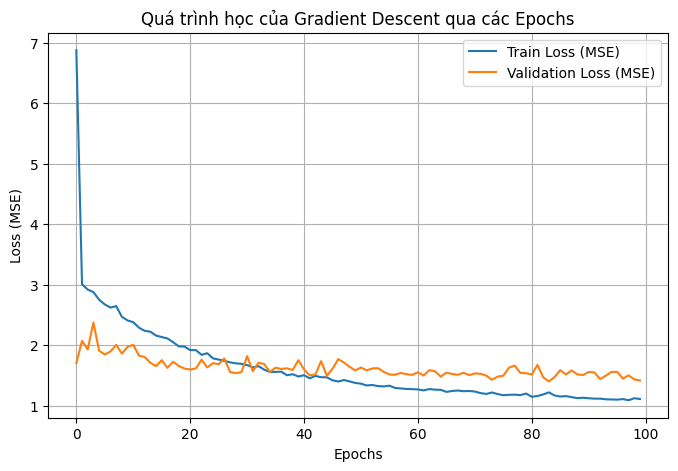


Sau 100 Epochs, trung bình mô hình dự đoán lệch: 1.01 điểm so với thực tế.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Quá trình học của Gradient Descent qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# In sai số cuối cùng
val_mae = history.history['val_mae'][-1]
print(f"\nSau 100 Epochs, trung bình mô hình dự đoán lệch: {val_mae:.2f} điểm so với thực tế.")